In [1]:
# Animating chirp scans
# Documentation of matplotlib.animation: https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.FuncAnimation.html

from matplotlib import patches as ptc
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.colors as colors
import pickle
import numpy as np
from IPython.display import HTML, Image


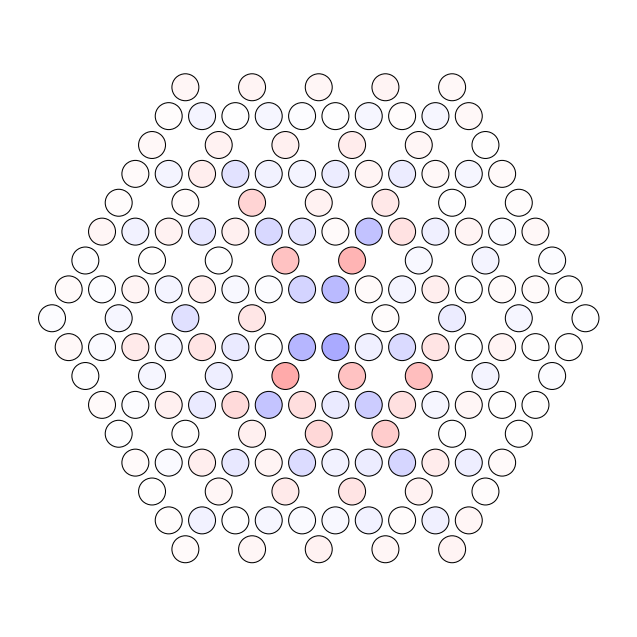

In [2]:
# making the animation with matplotlib.animation



folder = "../../../data/kagome-02.26.2022-center/" # Data folder

# Figure settings
freq = 14.4

# Load data from preprocessd file. Can only plot real space data at one frequency
# Real data format: [x_coord, y_coord, amplitude, phase]
with open(folder + "preprocessed_real/_{:.0f}.0_0.pkl".format(freq*1000),'rb') as f: 
    real_data = pickle.load(f)    
    


fig = plt.figure(figsize=(2.5,2.5), dpi=300)
ax = fig.gca()
ax.set_aspect("equal")
ax.set_xlim(-75, 75)
ax.set_ylim(-75, 75)
ax.axis('off')
max_amp_flat = np.max(real_data, axis=0)[2]
plt.yticks([])
plt.xticks([])

cavities = []
ampdata = []
phasedata = []
t = 0 # initial time
dt = 0.1 # time step
x_unit = 10*np.sqrt(3)/4 # conversion factor from x_coord unit to mm
y_unit = 7.5 # conversion factor from y_coord unit to mm
radius = 3.5 # Cavity radius: [mm]


frame_num = 60 # total frame number

for point in real_data: 
    x_center = point[0]*x_unit 
    y_center = point[1]*y_unit 
    
    
    ampdata.append(point[2])
    # If you want to rescale the amplitude color map, uncomment the line below
    # ampdata.append(np.sqrt(point[2])*np.sqrt(max_amp))
    phasedata.append(point[3])
    pressure = ampdata[-1]*np.sin(np.deg2rad(phasedata[-1]))

    # plot the 
    circle = ptc.Ellipse((x_center, y_center), 
                     width = radius*2, 
                     height = radius*2, 
                     edgecolor='black', 
                     facecolor = plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)),
                     fill = True, 
                     alpha = 1,
                     linewidth = 0.25)
    cavities.append(circle)
    ax.add_patch(cavities[-1])
    
def init():
    """initialize animation"""
    global cavities
      
    for i in range(len(cavities)):
        pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]))  
        cavities[i].set_facecolor(plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)))
                             
    return cavities
    
def animate(j):
    """perform animation step"""
    global t, dt, cavities, ampdata, phasedata
    t += dt
                            
    for i in range(len(cavities)):
        pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]+j*360/frame_num))
        cavities[i].set_facecolor(plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)))
                             
    return cavities

# creating the animation
ani = animation.FuncAnimation(fig, animate, frames = frame_num, interval = 2, blit = True, init_func = init)

In [3]:
# saving the animation in a gif file
filename = '{:.2f}kHz.gif'.format(freq)
folder = '../../../output/paper_new/animations/'
ani.save(folder + filename, writer = 'imagemagick', fps = 120)

MovieWriter imagemagick unavailable; using Pillow instead.


In [4]:
# displaying the animation (works in jupyter notebook but might not work in vs code)

Image(url = folder + 'animations/' + filename)

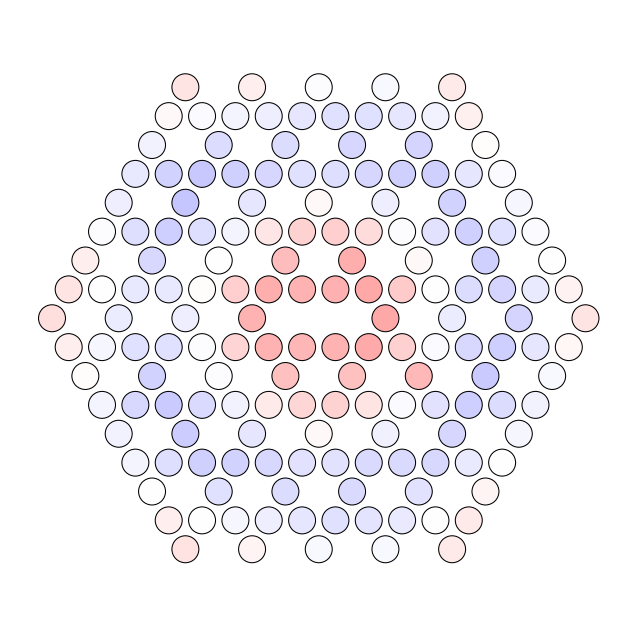

In [5]:
# making the animation with matplotlib.animation



folder = "../../../data/kagome-02.26.2022-center/" # Data folder

# Figure settings
freq = 4

# Load data from preprocessd file. Can only plot real space data at one frequency
# Real data format: [x_coord, y_coord, amplitude, phase]
with open(folder + "preprocessed_real/_{:.0f}.0_0.pkl".format(freq*1000),'rb') as f: 
    real_data = pickle.load(f)    
    


fig = plt.figure(figsize=(2.5,2.5), dpi=300)
ax = fig.gca()
ax.set_aspect("equal")
ax.set_xlim(-75, 75)
ax.set_ylim(-75, 75)
ax.axis('off')
plt.yticks([])
plt.xticks([])

cavities = []
ampdata = []
phasedata = []
t = 0 # initial time
dt = 0.1 # time step
x_unit = 10*np.sqrt(3)/4 # conversion factor from x_coord unit to mm
y_unit = 7.5 # conversion factor from y_coord unit to mm
radius = 3.5 # Cavity radius: [mm]


frame_num = 60 # total frame number

for point in real_data: 
    x_center = point[0]*x_unit 
    y_center = point[1]*y_unit 
    
    
    ampdata.append(point[2])
    # If you want to rescale the amplitude color map, uncomment the line below
    # ampdata.append(np.sqrt(point[2])*np.sqrt(max_amp))
    phasedata.append(point[3])
    pressure = ampdata[-1]*np.sin(np.deg2rad(phasedata[-1]))

    # plot the 
    circle = ptc.Ellipse((x_center, y_center), 
                     width = radius*2, 
                     height = radius*2, 
                     edgecolor='black', 
                     facecolor = plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)),
                     fill = True, 
                     alpha = 1,
                     linewidth = 0.25)
    cavities.append(circle)
    ax.add_patch(cavities[-1])
    
def init():
    """initialize animation"""
    global cavities
      
    for i in range(len(cavities)):
        pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]))  
        cavities[i].set_facecolor(plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)))
                             
    return cavities
    
def animate(j):
    """perform animation step"""
    global t, dt, cavities, ampdata, phasedata
    t += dt
                            
    for i in range(len(cavities)):
        pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]+j*360/frame_num))
        cavities[i].set_facecolor(plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)))
                             
    return cavities

# creating the animation
ani = animation.FuncAnimation(fig, animate, frames = frame_num, interval = 2, blit = True, init_func = init)

In [6]:
# saving the animation in a gif file
filename = '{:.2f}kHz.gif'.format(freq)
folder = '../../../output/paper_new/animations/'
ani.save(folder + filename, writer = 'imagemagick', fps = 120)

MovieWriter imagemagick unavailable; using Pillow instead.
